# ADA-Projekt SoSe 2026 – Porto Seguro's Safe Driver Prediction
## Notebook 2: XGBoost

Aufbau nach der in der Gruppe abgestimmten Struktur: Datenbezug über die OpenML-API, einheitliches dtype-Schema und **gemeinsame Split-Indizes** aus `data/processed/`. Letzteres ist entscheidend für die Vergleichbarkeit – alle Modelle der Gruppe werden dadurch auf exakt denselben Zeilen trainiert und bewertet.

**Voraussetzungen:** `pip install pandas numpy matplotlib scikit-learn xgboost`

**Besonderheit dieses Notebooks:** Da alle Feature-Typen explizit gesetzt werden (`category`, `bool`, `float32`), kann XGBoost mit `enable_categorical=True` **nativ** damit arbeiten. Es wird also weder One-Hot-Encoding noch Imputation benötigt – fehlende Werte bleiben als `NaN` erhalten und werden vom Algorithmus selbst behandelt. Das spart erheblich Speicher (57 statt 227 Spalten) und Rechenzeit.

**Laufzeit:** erster Download ca. 125 MB (danach gecacht), Training je etwa 1–2 Minuten.

## Setup

In [1]:
import os
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from xgboost import XGBClassifier

SEED = 42
GINI_BASELINE = 0.2622          # logistische Regression aus Notebook 1

# Pfad zu den gemeinsamen Split-Indizes der Gruppe (ggf. anpassen)
SPLIT_PFAD = os.path.join("..", "..", "..", "data", "processed")
ABB_ORDNER = "abbildungen"
os.makedirs(ABB_ORDNER, exist_ok=True)

FARBE_0, FARBE_1 = "#4C72B0", "#C44E52"


def speichere_abbildung(fig, dateiname):
    pfad = os.path.join(ABB_ORDNER, dateiname)
    fig.savefig(pfad, dpi=300, bbox_inches="tight")
    print(f"   -> gespeichert: {pfad}")
    plt.show()


def gini(y_true, y_score):
    """Normalisierter Gini = 2 * AUC - 1 (Metrik der Kaggle-Competition)."""
    return 2 * roc_auc_score(y_true, y_score) - 1

## Dataframe

`fetch_openml` lädt Datensatz 42742 direkt von OpenML und cached ihn lokal. Anders als bei den Kaggle-CSVs gibt es hier **keine `id`-Spalte**, `target` steht **an erster Stelle**, und fehlende Werte sind als `NaN` kodiert (nicht als −1).

In [2]:
t0 = time.time()
df_raw = fetch_openml(data_id=42742, as_frame=True).frame
print(f"geladen in {time.time() - t0:.0f}s | shape: {df_raw.shape}")
df_raw.head()

geladen in 16s | shape: (595212, 58)


,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2.0,2,5.0,1,0,0,1,0,0,...,9.0,1.0,5.0,8.0,0,1,1,0,0,1
1,0,1.0,1,7.0,0,0,0,0,1,0,...,3.0,1.0,1.0,9.0,0,1,1,0,1,0
2,0,5.0,4,9.0,1,0,0,0,1,0,...,4.0,2.0,7.0,7.0,0,1,1,0,1,0
3,0,0.0,1,2.0,0,0,1,0,0,0,...,2.0,2.0,4.0,9.0,0,0,0,0,0,0
4,0,0.0,2,0.0,1,0,1,0,0,0,...,3.0,1.0,1.0,3.0,0,0,0,1,1,0


### Feature-Gruppen und dtypes

Die Typzuordnung folgt den Namenssuffixen. Bewusst gewählte dtypes:

- **`category`** für `_cat` – ermöglicht XGBoosts native Kategorienbehandlung
- **`bool`** für `_bin`, sofern keine fehlenden Werte vorliegen (sonst `Int8`, der nullable Integer-Typ)
- **`float32`** für die übrigen – halbiert den Speicher gegenüber `float64`; XGBoost rechnet intern ohnehin in dieser Genauigkeit

**Wichtiges Detail:** Die Kategorien werden zuvor auf **ganzzahlig** normalisiert (`Int16`). Kommen sie als Fließkomma- oder Textwerte an, bricht XGBoost sonst mit der Meldung *"Category index from DataFrame has floating point dtype"* ab. Der Umweg über `pd.to_numeric` macht die Zelle unabhängig davon, in welcher Form OpenML die Werte liefert.

In [3]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    # erst ganzzahlig, dann category (NaN bleibt erhalten)
    werte = pd.to_numeric(df_raw[col].astype("object"), errors="coerce")
    df_raw[col] = werte.astype("Int16").astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

print(f"feat_cols: {len(feat_cols)} | cat: {len(cat_cols)} | bin: {len(bin_cols)} | num: {len(num_cols)}")
print("dtypes:", dict(df_raw.dtypes.astype(str).value_counts()))
print(f"Speicher df_raw: {df_raw.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
print(f"fehlende Werte: cat={int(df_raw[cat_cols].isna().sum().sum())}, "
      f"num={int(df_raw[num_cols].isna().sum().sum())}, bin={int(df_raw[bin_cols].isna().sum().sum())}")

feat_cols: 57 | cat: 14 | bin: 17 | num: 26
dtypes: {'float32': np.int64(26), 'bool': np.int64(18), 'category': np.int64(14)}
Speicher df_raw: 77 MB
fehlende Werte: cat=696060, num=150398, bin=0


### Split-Indizes

Die Indizes werden aus `data/processed/` geladen, damit **alle Gruppenmitglieder auf identischen Zeilen arbeiten** – nur so sind die Modellergebnisse direkt vergleichbar.

Falls die Dateien noch nicht existieren, erzeugt die Zelle sie einmalig (stratifiziert, 80/10/10) und speichert sie ab. **Diese Dateien müssen dann in der Gruppe geteilt werden**; erzeugt sie jede selbst neu, entstehen unterschiedliche Splits und die Ergebnisse sind nicht mehr vergleichbar.

Zur Aufteilung: `train` dient dem Training, `val` dem Early Stopping und der Hyperparameter-Wahl, `test` bleibt bis zur finalen Bewertung unangetastet.

In [4]:
os.makedirs(SPLIT_PFAD, exist_ok=True)
dateien = {name: os.path.join(SPLIT_PFAD, f"{name}_idx.npy") for name in ("train", "val", "test")}

if all(os.path.exists(p) for p in dateien.values()):
    idx_train = np.load(dateien["train"])
    idx_val = np.load(dateien["val"])
    idx_test = np.load(dateien["test"])
    print("Split-Indizes aus Dateien geladen.")
else:
    print("Keine Split-Dateien gefunden -> werden einmalig erzeugt (80/10/10, stratifiziert).")
    alle_idx = np.arange(len(df_raw))
    ziel = df_raw["target"].to_numpy()
    idx_train, idx_rest = train_test_split(
        alle_idx, test_size=0.2, stratify=ziel, random_state=SEED)
    idx_val, idx_test = train_test_split(
        idx_rest, test_size=0.5, stratify=ziel[idx_rest], random_state=SEED)
    for name, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
        np.save(dateien[name], idx)
    print(f"   gespeichert unter: {os.path.abspath(SPLIT_PFAD)}")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)],
    }
)

Keine Split-Dateien gefunden -> werden einmalig erzeugt (80/10/10, stratifiziert).
   gespeichert unter: C:\data\processed


train    [476169, 476169, 476169]
val         [59521, 59521, 59521]
test        [59522, 59522, 59522]
dtype: object

In [5]:
# Kontrolle: Stratifizierung erhalten?
print("Positivrate  train: {:.3f} %  |  val: {:.3f} %  |  test: {:.3f} %".format(
    y_train.mean() * 100, y_val.mean() * 100, y_test.mean() * 100))
print("Ueberschneidungen zwischen den Mengen:",
      len(set(idx_train) & set(idx_val)), len(set(idx_train) & set(idx_test)),
      len(set(idx_val) & set(idx_test)), "(alle sollen 0 sein)")

Positivrate  train: 3.645 %  |  val: 3.644 %  |  test: 3.646 %
Ueberschneidungen zwischen den Mengen: 0 0 0 (alle sollen 0 sein)


## XGBoost

**Klassenungleichgewicht:** `scale_pos_weight` entspricht dem Verhältnis negativer zu positiver Fälle (≈ 26,4) und ist das XGBoost-Pendant zu `class_weight="balanced"`.

**Early Stopping:** `n_estimators` wird bewusst hoch gesetzt; das Training bricht ab, sobald die AUC auf `x_val` 50 Runden lang nicht mehr steigt. Das bestimmt die Baumanzahl datengetrieben statt per Schätzung.

**`enable_categorical=True`:** XGBoost verarbeitet die `category`-Spalten direkt und sucht optimale Kategorien-Aufteilungen, statt sie in Dummy-Spalten aufzublähen. Zusammen mit `tree_method="hist"` ist das die schnelle und speicherschonende Variante.

Die übrigen Hyperparameter (`max_depth=5`, `min_child_weight=10`, Subsampling) halten die Bäume flach – bei 3,6 % Positivrate sonst schnell Overfitting. Es sind **begründete Startwerte, keine optimierten**; die systematische Suche steht noch aus.

In [6]:
scale_pos_weight = (~y_train).sum() / y_train.sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=2000,              # Obergrenze, Early Stopping bricht frueher ab
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    enable_categorical=True,        # native Kategorienbehandlung
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=SEED,
    n_jobs=-1,
)

t0 = time.time()
model.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose=100)
print(f"\nTrainingsdauer: {time.time() - t0:.0f}s")
print(f"beste Iteration: {model.best_iteration} von {model.n_estimators}")

scale_pos_weight = 26.44
[0]	validation_0-auc:0.59342
[100]	validation_0-auc:0.62930
[200]	validation_0-auc:0.62859
[204]	validation_0-auc:0.62856

Trainingsdauer: 19s
beste Iteration: 154 von 2000


### Bewertung

`val` diente dem Early Stopping und ist damit nicht mehr völlig unabhängig – die **ehrliche Schätzung der Generalisierung liefert `test`**, das bis hierher unangetastet blieb.

In [7]:
ergebnisse = {}
for name, xx, yy in [("val", x_val, y_val), ("test", x_test, y_test)]:
    score = model.predict_proba(xx)[:, 1]
    ergebnisse[name] = {
        "score": score,
        "auc": roc_auc_score(yy, score),
        "gini": gini(yy, score),
        "ap": average_precision_score(yy, score),
    }
    print(f"{name:5s}  AUC={ergebnisse[name]['auc']:.4f}  "
          f"Gini={ergebnisse[name]['gini']:.4f}  AP={ergebnisse[name]['ap']:.4f}")

print(f"\nBaseline LogReg (Notebook 1): Gini = {GINI_BASELINE:.4f}")
print(f"Differenz auf test:           {ergebnisse['test']['gini'] - GINI_BASELINE:+.4f}")

val    AUC=0.6306  Gini=0.2613  AP=0.0635
test   AUC=0.6335  Gini=0.2670  AP=0.0659

Baseline LogReg (Notebook 1): Gini = 0.2622
Differenz auf test:           +0.0048


### ROC- und Precision-Recall-Kurve (Testdaten)

   -> gespeichert: abbildungen\abb_12_xgboost_roc_pr.png


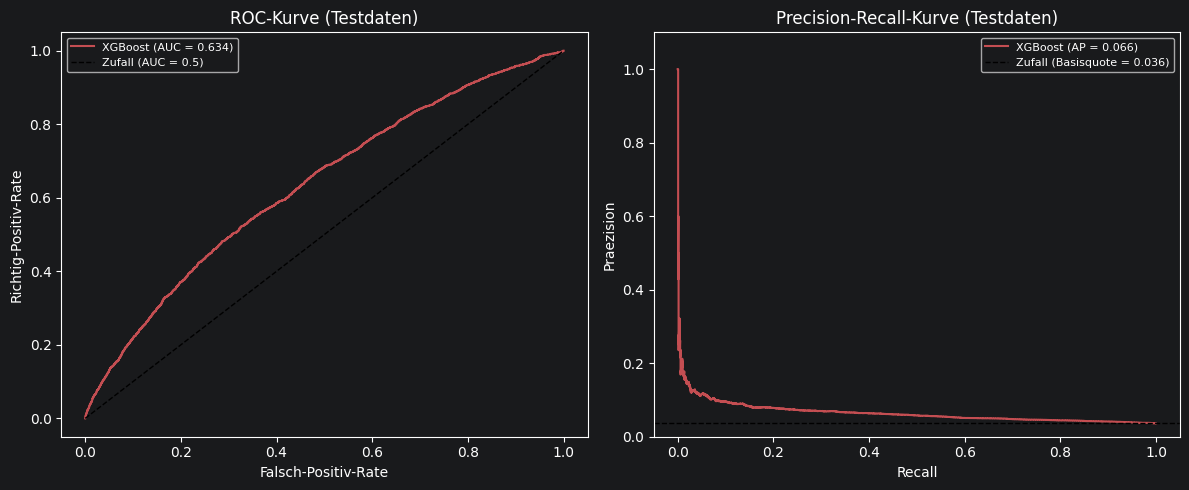

In [8]:
score_test = ergebnisse["test"]["score"]
fpr, tpr, _ = roc_curve(y_test, score_test)
prec, rec, _ = precision_recall_curve(y_test, score_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(fpr, tpr, color=FARBE_1, label=f"XGBoost (AUC = {ergebnisse['test']['auc']:.3f})")
ax1.plot([0, 1], [0, 1], "k--", linewidth=1, label="Zufall (AUC = 0.5)")
ax1.set_xlabel("Falsch-Positiv-Rate"); ax1.set_ylabel("Richtig-Positiv-Rate")
ax1.set_title("ROC-Kurve (Testdaten)"); ax1.legend(fontsize=8)

ax2.plot(rec, prec, color=FARBE_1, label=f"XGBoost (AP = {ergebnisse['test']['ap']:.3f})")
ax2.axhline(y_test.mean(), color="black", linestyle="--", linewidth=1,
            label=f"Zufall (Basisquote = {y_test.mean():.3f})")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Praezision")
ax2.set_title("Precision-Recall-Kurve (Testdaten)")
ax2.set_ylim(0, max(0.15, float(np.nanmax(prec[:-1])) * 1.1)); ax2.legend(fontsize=8)
fig.tight_layout()
speichere_abbildung(fig, "abb_12_xgboost_roc_pr.png")

### Trainingsverlauf

Die Validierungs-AUC je Boosting-Runde. Die gestrichelte Linie markiert die von Early Stopping gewählte Iteration – danach gab es keine Verbesserung mehr.

   -> gespeichert: abbildungen\abb_13_xgboost_trainingsverlauf.png


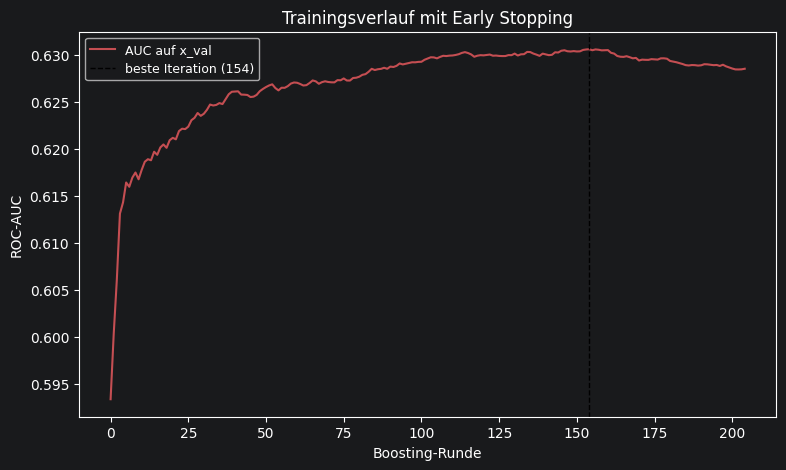

In [9]:
verlauf = model.evals_result()["validation_0"]["auc"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(verlauf)), verlauf, color=FARBE_1, linewidth=1.5, label="AUC auf x_val")
ax.axvline(model.best_iteration, color="black", linestyle="--", linewidth=1,
           label=f"beste Iteration ({model.best_iteration})")
ax.set_xlabel("Boosting-Runde"); ax.set_ylabel("ROC-AUC")
ax.set_title("Trainingsverlauf mit Early Stopping"); ax.legend(fontsize=9)
speichere_abbildung(fig, "abb_13_xgboost_trainingsverlauf.png")

### Feature Importance

Gezeigt wird der `gain` – der mittlere Zugewinn an Trennschärfe je Split. Da keine One-Hot-Spalten entstehen, entspricht **ein Balken genau einem Feature**, was die Lesbarkeit gegenüber der One-Hot-Variante deutlich verbessert.

**Vorsicht:** Importance-Werte sind keine Kausalaussagen; bei korrelierten Features (siehe Korrelationsmatrix in Notebook 1) verteilt sich die Wichtigkeit oft willkürlich auf einen der Partner.

   -> gespeichert: abbildungen\abb_14_xgboost_feature_importance.png


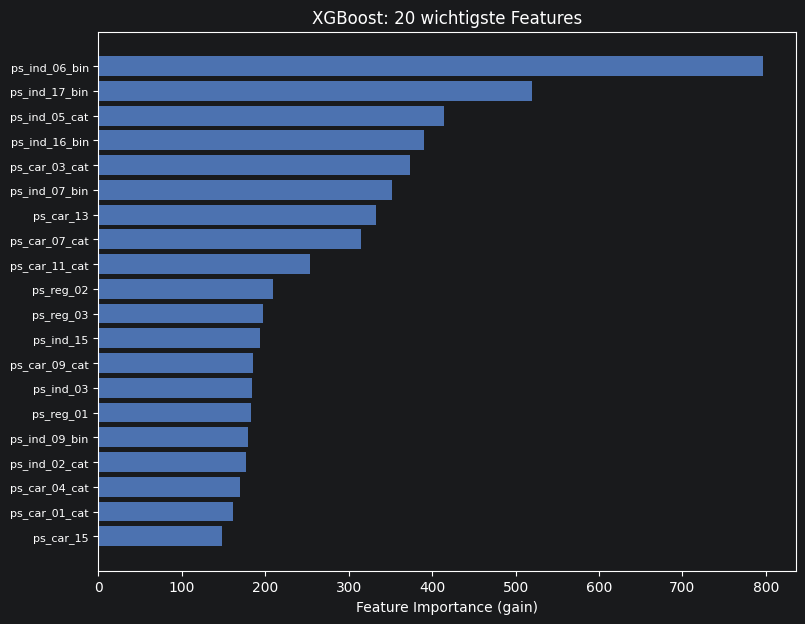

Top 10:
ps_ind_06_bin    796.27
ps_ind_17_bin    519.84
ps_ind_05_cat    414.21
ps_ind_16_bin    390.02
ps_car_03_cat    373.78
ps_ind_07_bin    351.51
ps_car_13        332.69
ps_car_07_cat    315.24
ps_car_11_cat    253.33
ps_reg_02        209.36
dtype: float64

Darunter calc-Features: keine


In [10]:
wichtigkeit = pd.Series(model.get_booster().get_score(importance_type="gain"))
wichtigkeit = wichtigkeit.sort_values(ascending=False)
top = wichtigkeit.head(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top.values, color=FARBE_0)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost: 20 wichtigste Features")
ax.tick_params(axis="y", labelsize=8)
speichere_abbildung(fig, "abb_14_xgboost_feature_importance.png")

print("Top 10:")
print(wichtigkeit.head(10).round(2))
print("\nDarunter calc-Features:",
      [f for f in wichtigkeit.head(20).index if "_calc_" in f] or "keine")

## Test der EDA-Hypothese: Bringen die `calc`-Features etwas?

Die EDA in Notebook 1 ergab, dass die 20 `ps_calc_*`-Features praktisch keinen Zusammenhang zur Zielvariable zeigen (max. |r| = 0,0019) und auch untereinander unkorreliert sind – die Korrelationsmatrix je Themengruppe blieb im calc-Panel vollständig leer.

Eine Korrelationstabelle ist jedoch kein Beweis. Deshalb wird hier **empirisch geprüft**: dasselbe Modell, dieselben Hyperparameter, dieselben Split-Indizes – nur ohne `calc`-Features.

In [11]:
feat_ohne_calc = [col for col in feat_cols if "_calc_" not in col]
print(f"{len(feat_cols)} -> {len(feat_ohne_calc)} Features "
      f"({len(feat_cols) - len(feat_ohne_calc)} calc-Features entfernt)")

model_ohne = XGBClassifier(
    n_estimators=2000, learning_rate=0.05, max_depth=5, min_child_weight=10,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight, tree_method="hist", enable_categorical=True,
    eval_metric="auc", early_stopping_rounds=50, random_state=SEED, n_jobs=-1,
)
t0 = time.time()
model_ohne.fit(x_train[feat_ohne_calc], y_train,
               eval_set=[(x_val[feat_ohne_calc], y_val)], verbose=False)
dauer_ohne = time.time() - t0

gini_ohne_test = gini(y_test, model_ohne.predict_proba(x_test[feat_ohne_calc])[:, 1])

vergleich = pd.DataFrame({
    "Features": [len(feat_cols), len(feat_ohne_calc)],
    "beste Iteration": [model.best_iteration, model_ohne.best_iteration],
    "Gini (test)": [round(ergebnisse["test"]["gini"], 4), round(gini_ohne_test, 4)],
}, index=["mit calc", "ohne calc"])
print(vergleich)
print(f"\nDifferenz Gini (ohne - mit): {gini_ohne_test - ergebnisse['test']['gini']:+.4f}")

57 -> 37 Features (20 calc-Features entfernt)
           Features  beste Iteration  Gini (test)
mit calc         57              154       0.2670
ohne calc        37              183       0.2661

Differenz Gini (ohne - mit): -0.0009


### Einordnung

**Grenzen dieser Aussage** – wichtig für die Reflexion im Portfolio: Der Unterschied beruht auf **einem einzigen** Split. Ob er über der zufälligen Streuung liegt, lässt sich erst mit einer Kreuzvalidierung beurteilen, bei der zusätzlich die Streuung über die Folds anzugeben wäre. Belastbar ist an dieser Stelle nur die schwächere Aussage: *Die calc-Features werden nicht benötigt.* Das genügt, um sie in den folgenden Modellen wegzulassen und Rechenzeit zu sparen.

## Nächste Schritte

- **Kreuzvalidierung** (`StratifiedKFold`) auf `train` + `val`, mit Streuung über die Folds
- **Hyperparameter-Optimierung** (`RandomizedSearchCV` / `HalvingRandomSearchCV`) für `max_depth`, `learning_rate`, `min_child_weight`, `subsample`, `colsample_bytree`
- **Variantenvergleich:** native Kategorienbehandlung (dieses Notebook) gegen One-Hot-Encoding – interessant, weil beide Wege unterschiedliche Ergebnisse liefern können
- **Learning Curves:** Reicht eine Teilmenge der Daten für stabile Ergebnisse?
- **Modellvergleich** mit Decision Tree und Random Forest auf **denselben Split-Indizes**, Ergebnisse in einer gemeinsamen Tabelle und ROC-Abbildung
- **Feature Engineering:** Anzahl fehlender Werte pro Zeile als zusätzliches Feature (EDA-Befund aus Notebook 1)